In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("netflix_titles.csv")
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nFirst 5 records:\n")
df.head()

Dataset shape (rows, columns): (400, 11)

Column names:
 ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 records:



,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Silent Chronicles,M. Rossi,United Kingdom,"November 24, 2021",2021,TV-Y7,81 min,"Horror, Drama, Crime",A gripping story about revenge.
1,s2,Movie,Final Horizon,NaN,Spain,"July 19, 2012",2011,TV-MA,173 min,Action,A quirky story about survival.
2,s3,Movie,Golden Signal,J. Miller,South Korea,"May 20, 2003",2001,TV-MA,173 min,Reality-TV,A quirky story about ambition.
3,s4,Movie,Endless Shadow,NaN,Australia,"March 23, 2013",2009,PG,75 min,"Documentary, Thriller, Comedy",A heartfelt story about family.
4,s5,Movie,Lost Garden,K. Tanaka,Japan,"November 9, 2010",2009,PG,147 min,"Action, Kids, Documentary",A heartfelt story about love.


In [ ]:
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

show_id           0
type              0
title             0
director        109
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64


In [ ]:
df["director"] = df["director"].fillna("Not Specified")
df["country"] = df["country"].fillna("Unknown")
df.drop_duplicates(subset="show_id", inplace=True)
print("Cleaning done. Missing values now:\n")
print(df.isnull().sum())

Cleaning done. Missing values now:

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [ ]:
type_counts = df["type"].value_counts()
print(type_counts)

type
Movie      293
TV Show    107
Name: count, dtype: int64


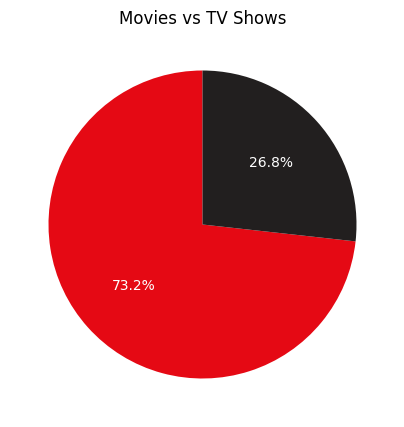

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
        colors=["#E50914", "#221f1f"], startangle=90,
        textprops={"color": "white"})
plt.title("Movies vs TV Shows")
plt.show()

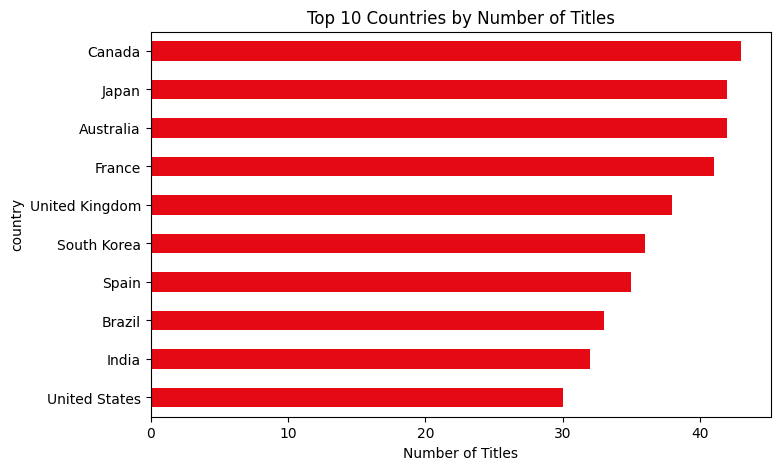

In [ ]:
top_countries = df["country"].value_counts().head(10)
plt.figure(figsize=(8,5))
top_countries.sort_values().plot(kind="barh", color="#E50914")
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.show()

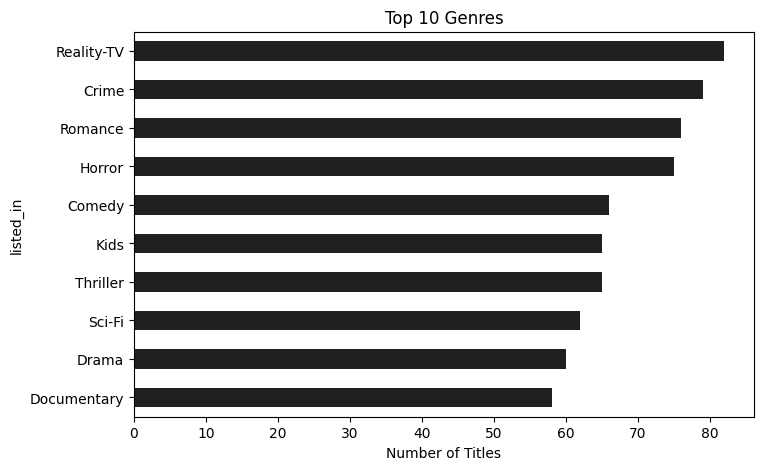

In [ ]:
genre_series = df["listed_in"].str.split(", ").explode()
top_genres = genre_series.value_counts().head(10)
plt.figure(figsize=(8,5))
top_genres.sort_values().plot(kind="barh", color="#221f1f")
plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.show()

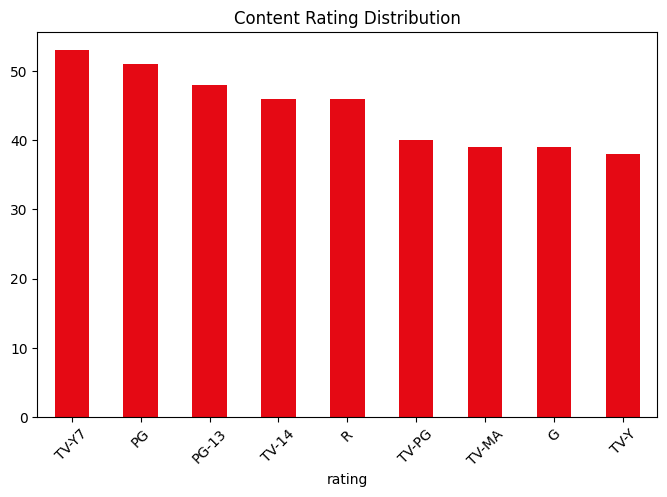

In [ ]:
rating_counts = df["rating"].value_counts()
plt.figure(figsize=(8,5))
rating_counts.plot(kind="bar", color="#E50914")
plt.title("Content Rating Distribution")
plt.xticks(rotation=45)
plt.show()

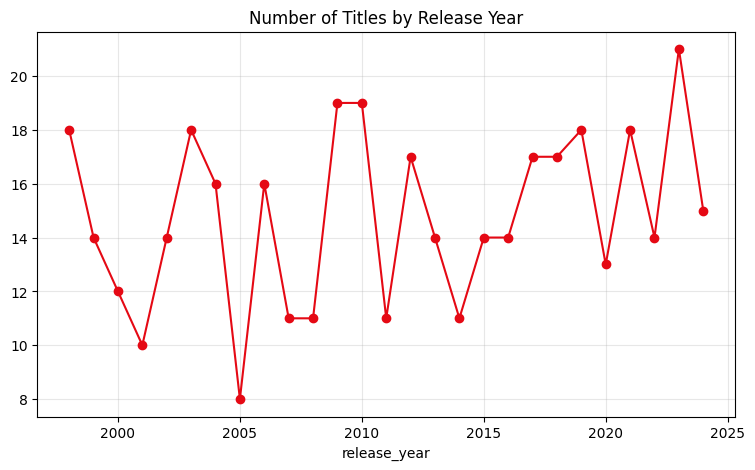

In [ ]:
titles_per_year = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(9,5))
titles_per_year.plot(kind="line", marker="o", color="#E50914")
plt.title("Number of Titles by Release Year")
plt.grid(alpha=0.3)
plt.show()

Average movie duration: 123.2 min
Shortest: 70 min | Longest: 175 min


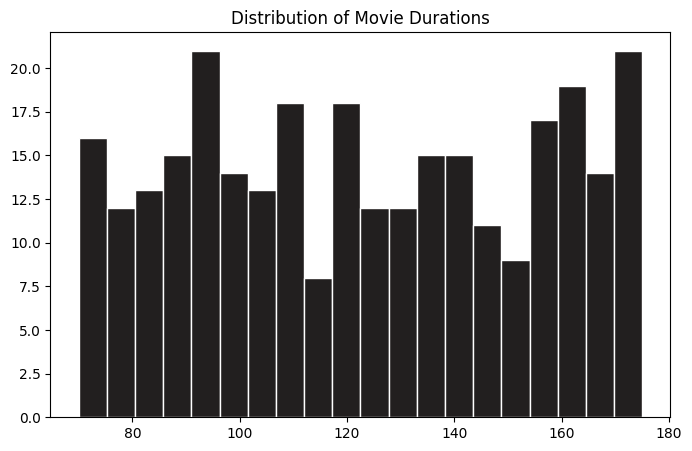

In [ ]:
movie_durations = (
    df[df["type"] == "Movie"]["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)
print("Average movie duration:", round(movie_durations.mean(), 1), "min")
print("Shortest:", movie_durations.min(), "min | Longest:", movie_durations.max(), "min")

plt.figure(figsize=(8,5))
plt.hist(movie_durations, bins=20, color="#221f1f", edgecolor="white")
plt.title("Distribution of Movie Durations")
plt.show()

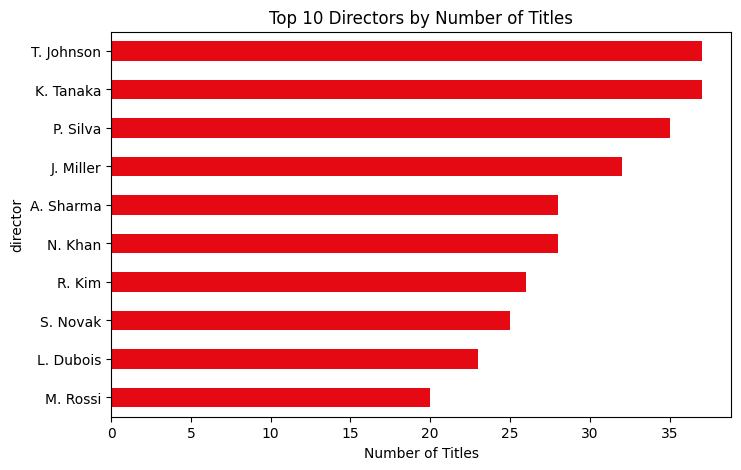

In [ ]:
top_directors = df[df["director"] != "Not Specified"]["director"].value_counts().head(10)
plt.figure(figsize=(8,5))
top_directors.sort_values().plot(kind="barh", color="#E50914")
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.show()

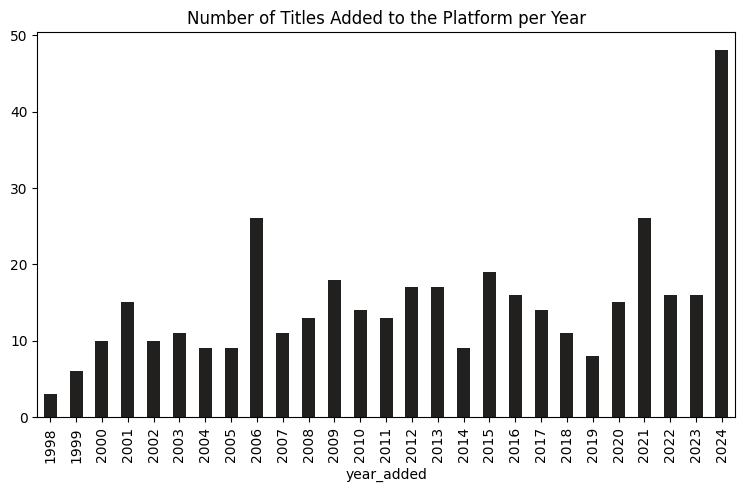

In [ ]:
df["year_added"] = df["date_added"].str.extract(r"(\d{4})").astype(int)
titles_added_per_year = df["year_added"].value_counts().sort_index()
plt.figure(figsize=(9,5))
titles_added_per_year.plot(kind="bar", color="#221f1f")
plt.title("Number of Titles Added to the Platform per Year")
plt.show()

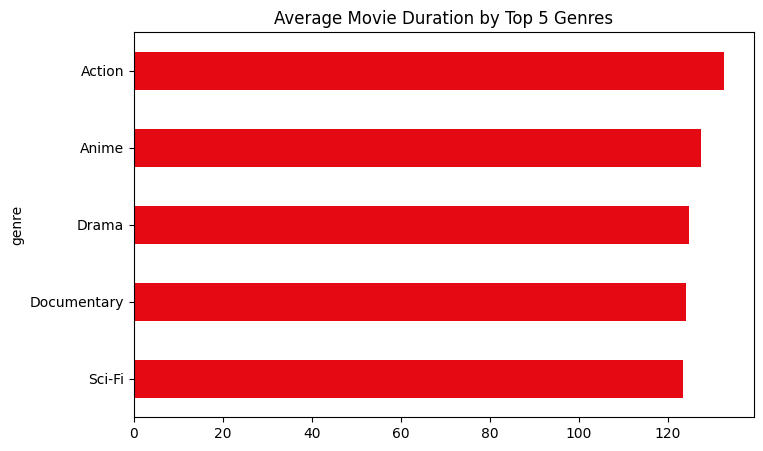

In [ ]:
genre_duration = df[df["type"] == "Movie"].copy()
genre_duration["duration_min"] = genre_duration["duration"].str.replace(" min", "", regex=False).astype(int)
genre_duration_exp = genre_duration.assign(genre=genre_duration["listed_in"].str.split(", ")).explode("genre")
avg_duration_by_genre = genre_duration_exp.groupby("genre")["duration_min"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
avg_duration_by_genre.sort_values().plot(kind="barh", color="#E50914")
plt.title("Average Movie Duration by Top 5 Genres")
plt.show()

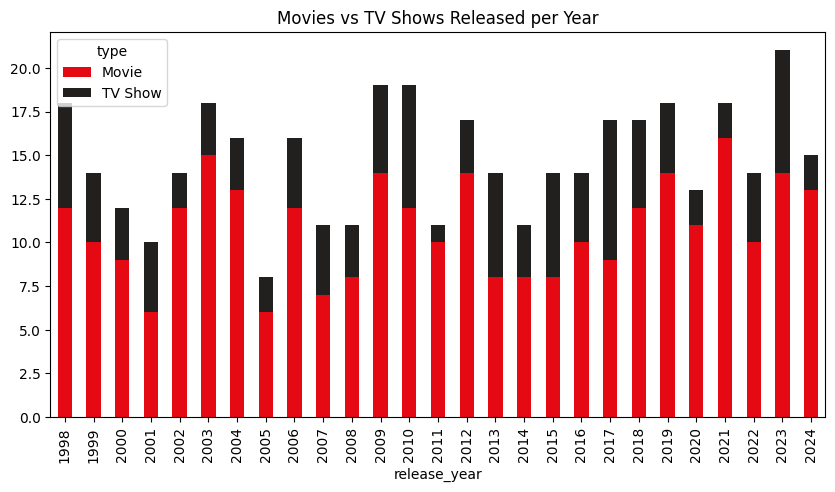

In [ ]:
pivot = df.pivot_table(index="release_year", columns="type", values="show_id", aggfunc="count").fillna(0)
plt.figure(figsize=(10,5))
pivot.plot(kind="bar", stacked=True, color=["#E50914", "#221f1f"], ax=plt.gca())
plt.title("Movies vs TV Shows Released per Year")
plt.xticks(rotation=90)
plt.show()

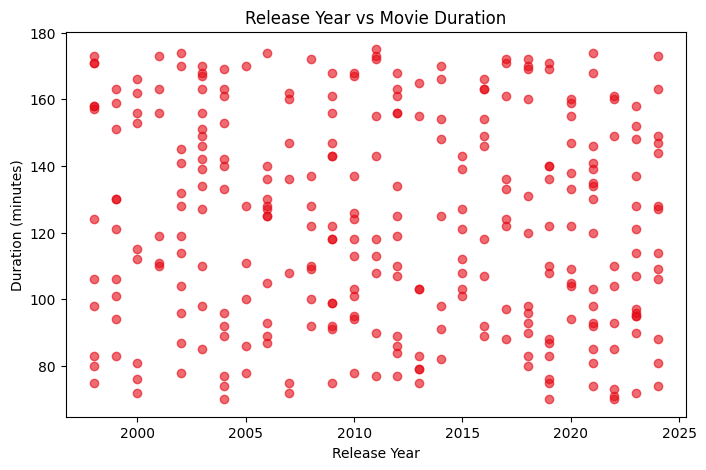

In [ ]:
movie_rows = df[df["type"] == "Movie"].copy()
movie_rows["duration_min"] = movie_rows["duration"].str.replace(" min", "", regex=False).astype(int)

plt.figure(figsize=(8,5))
plt.scatter(movie_rows["release_year"], movie_rows["duration_min"], alpha=0.6, color="#E50914")
plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")
plt.show()

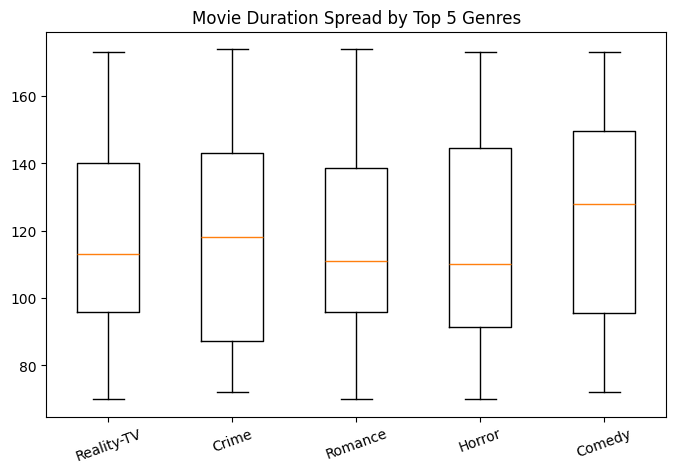

In [ ]:
top5_genres = genre_series.value_counts().head(5).index.tolist()
box_data = []
for g in top5_genres:
    mask = movie_rows["listed_in"].str.contains(g, regex=False)
    box_data.append(movie_rows.loc[mask, "duration_min"].values)

plt.figure(figsize=(8,5))
plt.boxplot(box_data, tick_labels=top5_genres)
plt.title("Movie Duration Spread by Top 5 Genres")
plt.xticks(rotation=20)
plt.show()

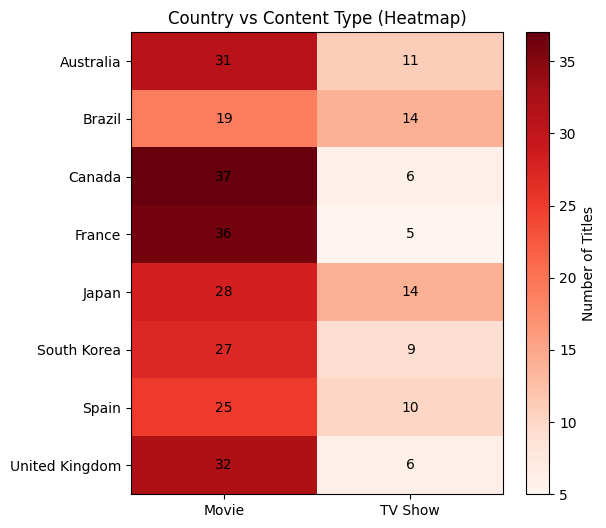

In [ ]:
top8_countries = df["country"].value_counts().head(8).index
cross = pd.crosstab(df[df["country"].isin(top8_countries)]["country"],
                     df[df["country"].isin(top8_countries)]["type"])

plt.figure(figsize=(6,6))
plt.imshow(cross.values, cmap="Reds", aspect="auto")
plt.xticks(range(len(cross.columns)), cross.columns)
plt.yticks(range(len(cross.index)), cross.index)
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        plt.text(j, i, cross.values[i, j], ha="center", va="center")
plt.title("Country vs Content Type (Heatmap)")
plt.colorbar(label="Number of Titles")
plt.show()

/tmp/ipykernel_5912/3703287696.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(genre_counts_all.index, rotation=45, ha="right")


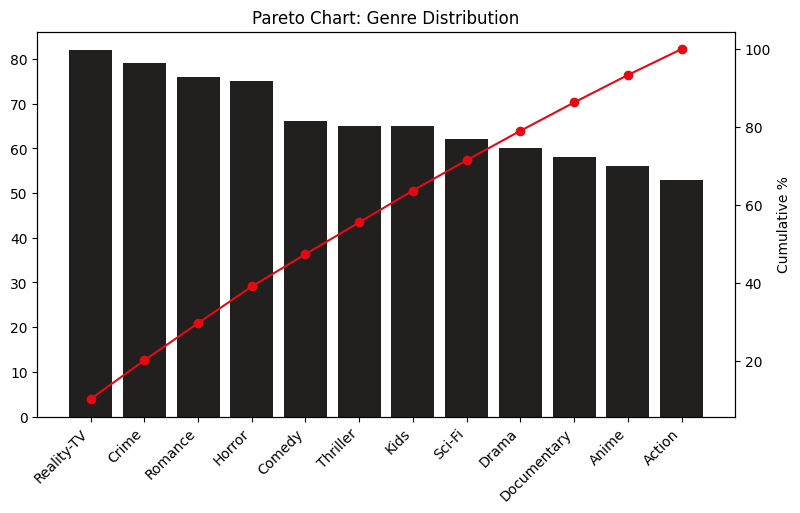

In [ ]:
genre_counts_all = genre_series.value_counts()
cum_pct = genre_counts_all.cumsum() / genre_counts_all.sum() * 100

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(genre_counts_all.index, genre_counts_all.values, color="#221f1f")
ax1.set_xticklabels(genre_counts_all.index, rotation=45, ha="right")
ax2 = ax1.twinx()
ax2.plot(genre_counts_all.index, cum_pct.values, color="#E50914", marker="o")
ax2.set_ylabel("Cumulative %")
plt.title("Pareto Chart: Genre Distribution")
plt.show()

In [ ]:
with open("summary_report.txt", "w") as f:
    f.write("MOVIE / NETFLIX DATASET ANALYZER - SUMMARY REPORT\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Total titles analysed : {len(df)}\n\n")
    f.write("Content type distribution:\n")
    f.write(type_counts.to_string() + "\n\n")
    f.write("Top 10 countries:\n")
    f.write(top_countries.to_string() + "\n\n")
    f.write("Top 10 genres:\n")
    f.write(top_genres.to_string() + "\n\n")
    f.write(f"Average movie duration: {round(movie_durations.mean(),1)} minutes\n")

print("Summary report created!")

from google.colab import files
files.download("summary_report.txt")

Summary report created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>